<a href="https://colab.research.google.com/github/Bienbaz/Simple-Linear-Regression-Marketing-ROI-Analysis/blob/main/regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression – Marketing ROI Analysis

## Project Objective
Analyze marketing channels (TV, Radio, Social Media) to determine which has the highest impact on Sales using Simple Linear Regression.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("marketing_and_sales_data_evaluate_lr.csv")

df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [6]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [7]:
df.isnull().sum()

,0
TV,10
Radio,4
Social_Media,6
Sales,6


In [8]:
df = df.dropna()

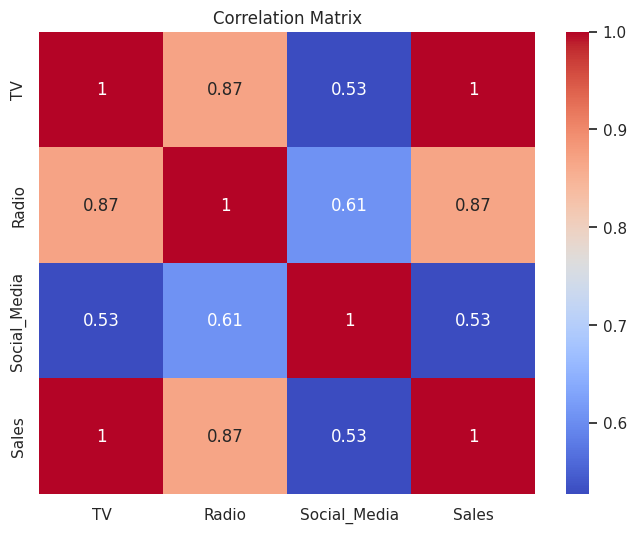

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

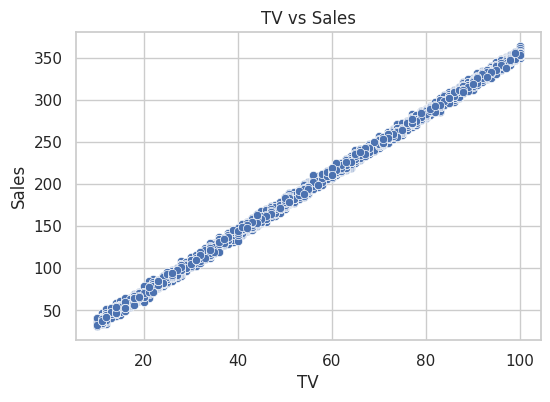

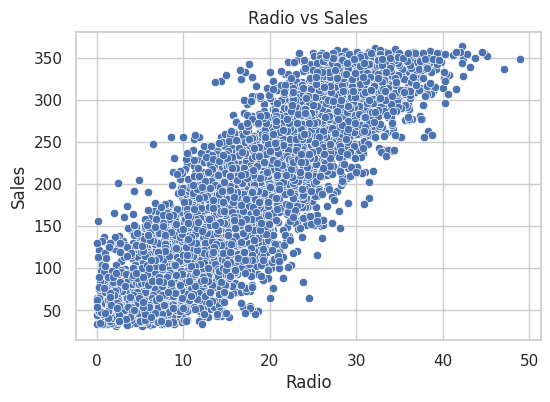

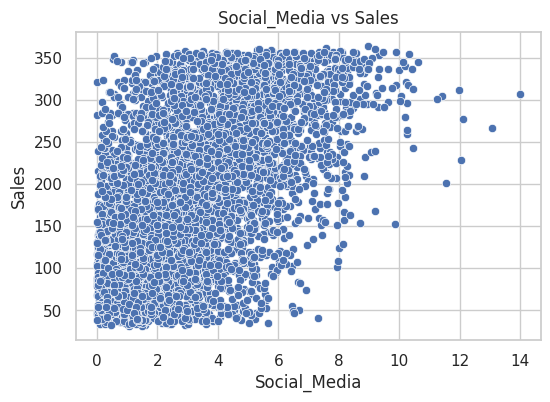

In [10]:
channels = ["TV", "Radio", "Social_Media"]

for col in channels:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df["Sales"])
    plt.title(f"{col} vs Sales")
    plt.show()

In [11]:
correlations = df.corr(numeric_only=True)["Sales"].sort_values(ascending=False)
correlations

,Sales
Sales,1.000000
TV,0.999497
Radio,0.868638
Social_Media,0.527446


In [12]:
X = df[["TV"]]
y = df["Sales"]

X = sm.add_constant(X)

In [13]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:39:20   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

In [14]:
df["Predicted_Sales"] = model.predict(X)
df.head()

,TV,Radio,Social_Media,Sales,Predicted_Sales
0,16.0,6.566231,2.907983,54.732757,56.851733
1,13.0,9.237765,2.409567,46.677897,46.167191
2,41.0,15.886446,2.913410,150.177829,145.889585
3,83.0,30.020028,6.922304,298.246340,295.473177
4,15.0,8.437408,1.405998,56.594181,53.290219


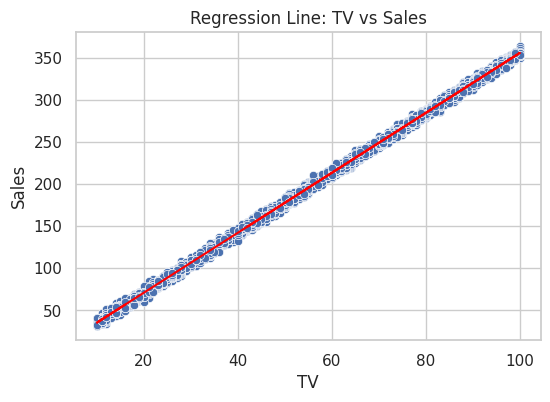

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["TV"], y=df["Sales"])
plt.plot(df["TV"], df["Predicted_Sales"], color="red")
plt.title("Regression Line: TV vs Sales")
plt.show()

In [16]:
residuals = model.resid
fitted = model.fittedvalues

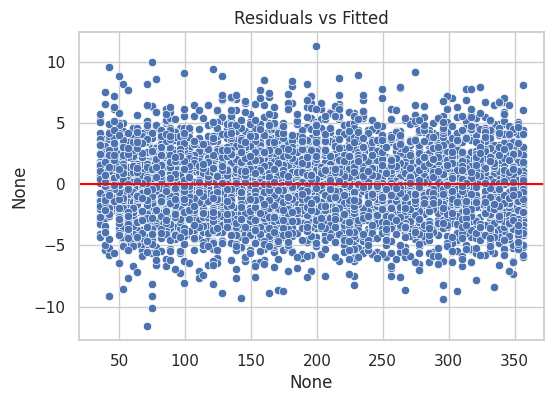

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color="red")
plt.title("Residuals vs Fitted")
plt.show()

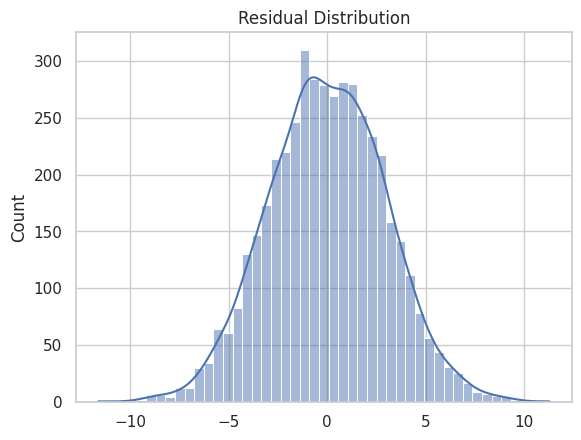

In [18]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

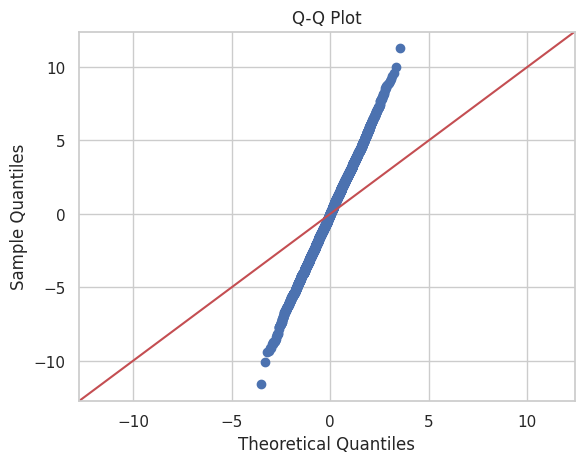

In [19]:
sm.qqplot(residuals, line="45")
plt.title("Q-Q Plot")
plt.show()

## Model Interpretation

- R-squared shows how much of Sales is explained by the marketing channel.
- Coefficient shows the impact of marketing spend on Sales.
- p-value shows statistical significance (if < 0.05, it's significant).

## Business Recommendation

Based on the regression analysis, the marketing channel with the highest coefficient and strongest correlation should receive more budget allocation.

This channel delivers the highest ROI impact on Sales and should be prioritized for future campaigns.